<a href="https://colab.research.google.com/github/samsarkar184/Self-Supervised-Learning/blob/main/SimCLR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [241]:
#imports
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader,Subset
from torchvision import transforms,datasets
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [243]:
#gpu check
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [244]:
#transformation of image
train_transform=transforms.Compose([transforms.RandomHorizontalFlip(),
                                    transforms.RandomResizedCrop(32,scale=(0.5,1.0)),
                                    transforms.RandomApply([
                                        transforms.ColorJitter(brightness=0.8,contrast=0.8,saturation=0.8,hue=0.2)
                                    ],p=0.8),
                                    transforms.RandomGrayscale(p=0.2),
                                    transforms.ToTensor()])

In [245]:
#import CIFAR-10 train dataset
train_dataset=datasets.CIFAR10(root="./data",
                               train=True,
                               download=True,
                               transform=None)

In [246]:
#import CIFAR-10 test dataset
transform=transforms.ToTensor()
test_dataset=datasets.CIFAR10(root="./data",
                              train=False,
                              download=True,
                              transform=transform)

In [247]:
#take a subset of the dataset for training and testing
train_subset=Subset(train_dataset,range(5000))
test_subset=Subset(test_dataset,range(1000))
train_loader=DataLoader(train_subset,batch_size=128,shuffle=True)
test_loader=DataLoader(test_subset,batch_size=128,shuffle=True)

In [248]:
# creating SimClr wrapper
from torch.utils.data import Dataset
class Simdataset(Dataset):
    def __init__(self,dataset,transform):
        self.dataset = dataset
        self.transform = transform
    def __len__(self):
        return len(self.dataset)
    def __getitem__(self, index):
        image = self.dataset[index][0]
        view_1 = self.transform(image)
        view_2 = self.transform(image)
        return view_1, view_2

In [249]:
# creating object of simdataset
sim_dataset = Simdataset(train_subset, train_transform)

In [250]:
# displaying the no. of samples and two augmented view
print("Number of samples:", len(sim_dataset))

view_1, view_2 = sim_dataset[0]

print("View 1 shape:", view_1.shape)
print("View 2 shape:", view_2.shape)

Number of samples: 5000
View 1 shape: torch.Size([3, 32, 32])
View 2 shape: torch.Size([3, 32, 32])


In [251]:
# creating SimClr DataLoader
from torch.utils.data import DataLoader
sim_loader = DataLoader(
    sim_dataset,
    batch_size = 128,
    shuffle = True,
    drop_last = True
)

In [252]:
# Testing the DataLoader
view_1_batch, view_2_batch = next(iter(sim_loader))
print("View 1 batch shape:", view_1_batch.shape)
print("View 2 batch shape:", view_2_batch.shape)

View 1 batch shape: torch.Size([128, 3, 32, 32])
View 2 batch shape: torch.Size([128, 3, 32, 32])


In [253]:
# build encoder
class Encoder(nn.Module):
  def __init__(self):
    super(Encoder,self).__init__()
    self.conv1=nn.Conv2d(3,32,kernel_size=3,padding=1)
    self.conv2=nn.Conv2d(32,64,kernel_size=3,padding=1)
    self.pool=nn.MaxPool2d(2,2)
    self.fc=nn.Linear(64*8*8,128)

  def forward(self,x):
    x=F.relu(self.conv1(x))
    x=self.pool(x)
    x=F.relu(self.conv2(x))
    x=self.pool(x)
    x=torch.flatten(x,1)
    x=self.fc(x)
    return x


In [254]:
#create Encoder object
encoder = Encoder()
encoder = encoder.to(device)

In [255]:
# checking encoder work
x = view_1_batch.to(device)
features = encoder(x)
print("Encoder output shape:", features.shape)

Encoder output shape: torch.Size([128, 128])


In [256]:
# build projection head
class ProjectionHead(nn.Module):
  def __init__(self):
    super(ProjectionHead, self).__init__()
    self.fc1 = nn.Linear(128,128)
    self.fc2 = nn.Linear(128,64)
  def forward(self, x):
    x = F.relu(self.fc1(x))
    x = self.fc2(x)
    return x


In [257]:
print("View 1 device:", view_1_batch.device)
print("Encoder device:", next(encoder.parameters()).device)
view_1_batch = view_1_batch.to(device)

View 1 device: cpu
Encoder device: cuda:0


In [258]:
projection_head = ProjectionHead().to(device)
print("Projection Head device:", next(projection_head.parameters()).device)

Projection Head device: cuda:0


In [259]:
# create projection head object and testing the encoder and projection head work
projection_head = ProjectionHead().to(device)
features = encoder(view_1_batch)
projections = projection_head(features)
print("Encoder output shape:",features.shape)
print("Projection output shape:",projections.shape)

Encoder output shape: torch.Size([128, 128])
Projection output shape: torch.Size([128, 64])


In [260]:
# processing both augmented views through encoder and projection head
view_2_batch = view_2_batch.to(device)
features_1 = encoder(view_1_batch)
features_2 = encoder(view_2_batch)
projections_1 = projection_head(features_1)
projections_2 = projection_head(features_2)
print("Projection 1 shape:",projections_1.shape)
print("Projection 2 shape:",projections_2.shape)

Projection 1 shape: torch.Size([128, 64])
Projection 2 shape: torch.Size([128, 64])


In [261]:
def nt_xent_loss(z1, z2, temperature=0.2):


    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)


    batch_size = z1.shape[0]


    z = torch.cat([z1, z2], dim=0)


    similarity = torch.matmul(z, z.T)

    similarity = similarity / temperature


    mask = torch.eye(2 * batch_size, dtype=torch.bool, device=z.device)

    similarity = similarity.masked_fill(mask, -float('inf'))


    positive_indices = torch.cat([
        torch.arange(batch_size, 2 * batch_size),
        torch.arange(0, batch_size)
    ]).to(z.device)


    loss = F.cross_entropy(similarity, positive_indices)

    return loss

In [262]:
# calling the function and displaying the loss value
loss = nt_xent_loss(projections_1, projections_2)

print("NT-Xent Loss:", loss.item())

NT-Xent Loss: 5.525376319885254


In [263]:
# create the optimizer
optimizer = torch.optim.Adam(
    list(encoder.parameters()) + list(projection_head.parameters()),
    lr=0.001
)

In [264]:
# SimClr training loop
num_epochs = 50

for epoch in range(num_epochs):

    total_loss = 0

    for view_1_batch, view_2_batch in sim_loader:

        view_1_batch = view_1_batch.to(device)
        view_2_batch = view_2_batch.to(device)

        features_1 = encoder(view_1_batch)
        features_2 = encoder(view_2_batch)

        projections_1 = projection_head(features_1)
        projections_2 = projection_head(features_2)

        loss = nt_xent_loss(projections_1, projections_2)

        optimizer.zero_grad()


        loss.backward()


        optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(sim_loader)

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {average_loss:.4f}")

Epoch [1/50], Loss: 4.7320
Epoch [2/50], Loss: 4.2132
Epoch [3/50], Loss: 3.9347
Epoch [4/50], Loss: 3.7809
Epoch [5/50], Loss: 3.6225
Epoch [6/50], Loss: 3.4205
Epoch [7/50], Loss: 3.3478
Epoch [8/50], Loss: 3.2657
Epoch [9/50], Loss: 3.2530
Epoch [10/50], Loss: 3.1769
Epoch [11/50], Loss: 3.1471
Epoch [12/50], Loss: 3.0552
Epoch [13/50], Loss: 3.0559
Epoch [14/50], Loss: 3.0012
Epoch [15/50], Loss: 2.9490
Epoch [16/50], Loss: 2.9537
Epoch [17/50], Loss: 2.9383
Epoch [18/50], Loss: 2.8928
Epoch [19/50], Loss: 2.8879
Epoch [20/50], Loss: 2.9003
Epoch [21/50], Loss: 2.8611
Epoch [22/50], Loss: 2.8521
Epoch [23/50], Loss: 2.8093
Epoch [24/50], Loss: 2.8207
Epoch [25/50], Loss: 2.7985
Epoch [26/50], Loss: 2.7979
Epoch [27/50], Loss: 2.7988
Epoch [28/50], Loss: 2.7499
Epoch [29/50], Loss: 2.7449
Epoch [30/50], Loss: 2.7518
Epoch [31/50], Loss: 2.7245
Epoch [32/50], Loss: 2.7470
Epoch [33/50], Loss: 2.7163
Epoch [34/50], Loss: 2.7096
Epoch [35/50], Loss: 2.7033
Epoch [36/50], Loss: 2.6887
E

In [265]:
# Saving the trained encoder
torch.save(encoder.state_dict(),"simclr_encoder.pth")

In [266]:
#freezing the encoder
for param in encoder.parameters():
  param.requires_grad=False
encoder.eval()

Encoder(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc): Linear(in_features=4096, out_features=128, bias=True)
)

In [267]:

#classifier head
classifier=nn.Linear(128,10).to(device)
print(classifier)

Linear(in_features=128, out_features=10, bias=True)


In [287]:
#optimizer and loss for classification head
criterion=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(
     list(encoder.parameters())+list(classifier.parameters()),
    lr=0.001
)

In [292]:
classification_transform = transforms.ToTensor()

In [293]:
classification_train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=False,
    transform=classification_transform
)

In [294]:
classification_train_subset = Subset(
    classification_train_dataset,
    range(5000)
)

In [295]:
classification_test_loader = DataLoader(
    classification_train_subset,
    batch_size=128,
    shuffle=True
)

In [296]:
# classification head loop
num_epochs=75
for epoch in range(num_epochs):
  total_loss=0
  classifier.train()
  for images,labels in classification_train_loader:
    images=images.to(device)
    labels=labels.to(device)


    features=encoder(images)

    outputs=classifier(features)
    loss=criterion(outputs,labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    total_loss+=loss.item()
  average_loss=total_loss/len(classification_train_loader)
  print(
        f"Epoch [{epoch+1}/{num_epochs}], "
        f"Loss: {average_loss:.4f}"
    )

Epoch [1/75], Loss: 1.3686
Epoch [2/75], Loss: 1.3903
Epoch [3/75], Loss: 1.3630
Epoch [4/75], Loss: 1.3731
Epoch [5/75], Loss: 1.3772
Epoch [6/75], Loss: 1.3791
Epoch [7/75], Loss: 1.3634
Epoch [8/75], Loss: 1.3589
Epoch [9/75], Loss: 1.3608
Epoch [10/75], Loss: 1.3567
Epoch [11/75], Loss: 1.3696
Epoch [12/75], Loss: 1.3533
Epoch [13/75], Loss: 1.3730
Epoch [14/75], Loss: 1.3626
Epoch [15/75], Loss: 1.3649
Epoch [16/75], Loss: 1.3802
Epoch [17/75], Loss: 1.3777
Epoch [18/75], Loss: 1.3733
Epoch [19/75], Loss: 1.3849
Epoch [20/75], Loss: 1.3644
Epoch [21/75], Loss: 1.3452
Epoch [22/75], Loss: 1.3680
Epoch [23/75], Loss: 1.3691
Epoch [24/75], Loss: 1.3764
Epoch [25/75], Loss: 1.3613
Epoch [26/75], Loss: 1.3499
Epoch [27/75], Loss: 1.3679
Epoch [28/75], Loss: 1.3710
Epoch [29/75], Loss: 1.3691
Epoch [30/75], Loss: 1.3694
Epoch [31/75], Loss: 1.3608
Epoch [32/75], Loss: 1.3464
Epoch [33/75], Loss: 1.3485
Epoch [34/75], Loss: 1.3599
Epoch [35/75], Loss: 1.3600
Epoch [36/75], Loss: 1.3663
E

In [297]:
images, labels = next(iter(classification_test_loader))

images = images.to(device)

with torch.no_grad():
    features = encoder(images)

print("Image shape:", images.shape)
print("Feature shape:", features.shape)
print(classifier)

Image shape: torch.Size([128, 3, 32, 32])
Feature shape: torch.Size([128, 128])
Linear(in_features=128, out_features=10, bias=True)


In [298]:
# Create CIFAR-10 test dataset for classification
classification_test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transforms.ToTensor()
)

In [299]:
# Take a subset of the test dataset
classification_test_subset = Subset(
    classification_test_dataset,
    range(1000)
)

In [300]:
# Create test DataLoader
classification_test_loader = DataLoader(
    classification_test_dataset,
    batch_size=128,
    shuffle=False
)

In [301]:
# Evaluate the trained classifier
classifier.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in classification_test_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Extract features using the frozen encoder
        features = encoder(images)

        # Classifier prediction
        outputs = classifier(features)

        # Get predicted class
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 49.59%


In [240]:
from sklearn.metrics import classification_report
classes = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]
print(classification_report(all_labels,all_predictions,target_names=classes))

NameError: name 'all_labels' is not defined

In [ ]:
#Create Classification Report
from sklearn.metrics import classification_report
classifier.eval()
all_predictions = []
all_labels = []
with torch.no_grad():
  for images, labels in classification_test_loader:
    images = images.to(device)
    features = encoder(images)
    outputs = classifier(features)
    predictions = torch.argmax(outputs, dim=1)
    all_predictions.extend(predictions.cpu().numpy())
    all_labels.extend(labels.numpy())
print(classification_report(all_labels,all_predictions))

              precision    recall  f1-score   support

           0       0.47      0.43      0.45      1000
           1       0.43      0.41      0.42      1000
           2       0.25      0.14      0.18      1000
           3       0.27      0.12      0.16      1000
           4       0.30      0.23      0.26      1000
           5       0.34      0.40      0.37      1000
           6       0.33      0.65      0.44      1000
           7       0.37      0.36      0.37      1000
           8       0.50      0.57      0.54      1000
           9       0.39      0.46      0.42      1000

    accuracy                           0.38     10000
   macro avg       0.37      0.38      0.36     10000
weighted avg       0.37      0.38      0.36     10000



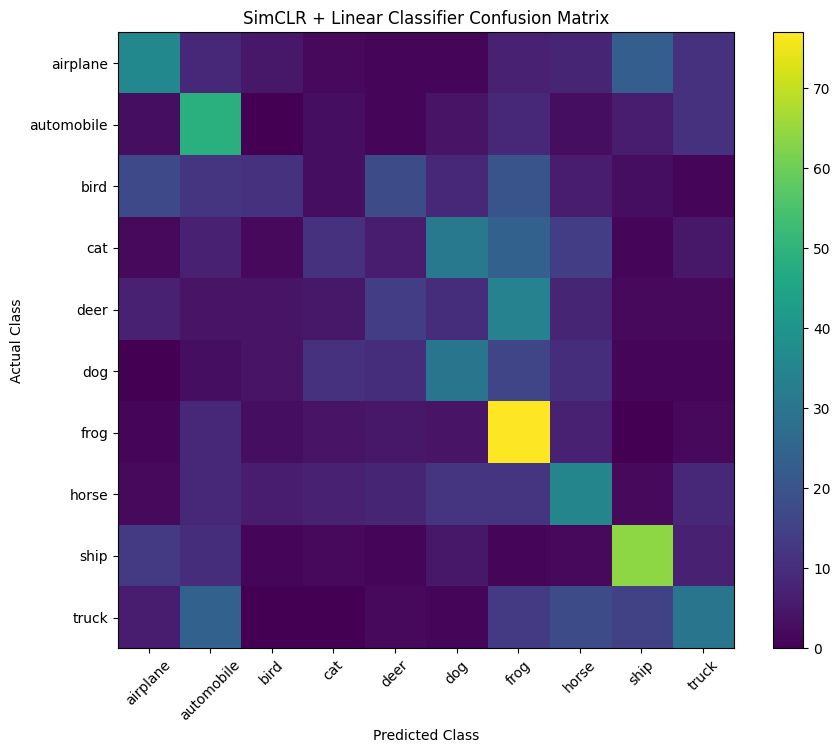

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_predictions)

classes = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

plt.figure(figsize=(10, 8))

plt.imshow(cm)

plt.xticks(range(10), classes, rotation=45)
plt.yticks(range(10), classes)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("SimCLR + Linear Classifier Confusion Matrix")

plt.colorbar()

plt.show()